# Line plots

The default figure for most papers, and the one where the property cycle matters most: a reader who
prints your paper in greyscale must still be able to tell the curves apart.

All data here is synthetic and all axis labels are deliberately generic — this notebook is about how a
figure is built and styled, not about any particular measurement.

In [1]:
%matplotlib inline

# Jupyter crops every inline preview with bbox_inches="tight". That defeats the exact column widths
# this package exists to guarantee, and because the themes sit the axes close to the canvas edge, the
# crop slices through the top and right spines. Turn it off so previews match the files jf.save() writes.
%config InlineBackend.print_figure_kwargs = {"bbox_inches": None}

# jf.save() reports what it wrote through the "journalfig" logger instead of printing. Raise that one
# logger -- a blanket logging.basicConfig(level="INFO") also switches on fontTools, which logs a dozen
# subsetting lines per PDF.
import logging

logging.basicConfig(format="%(message)s")
logging.getLogger("journalfig").setLevel(logging.INFO)

import numpy as np
import matplotlib.pyplot as plt

import journalfig as jf

# The themes render previews at 600 dpi, which makes every embedded image in a notebook large. This
# only touches the on-screen preview; jf.save() exports at savefig.dpi regardless.
PREVIEW_DPI = 150


def preview(journal, **kwargs):
    """Apply a theme, then drop the on-screen DPI so this notebook stays light."""
    jf.use(journal, **kwargs)
    plt.rcParams["figure.dpi"] = PREVIEW_DPI


rng = np.random.default_rng(0)
print("journalfig", jf.__version__, "| themes:", jf.JOURNALS)

journalfig 0.5.0 | themes: ('nature', 'aps', 'elsevier')


## The property cycle

The themes pair **colour with linestyle**, so eight curves stay distinguishable without colour. The
palette is Okabe–Ito and is identical across all three themes, so retargeting never changes colours.

Markers are deliberately left out of the cycle: a marker there would decorate every point of a dense
curve. Use `jf.MARKER_CYCLE` when you want them.

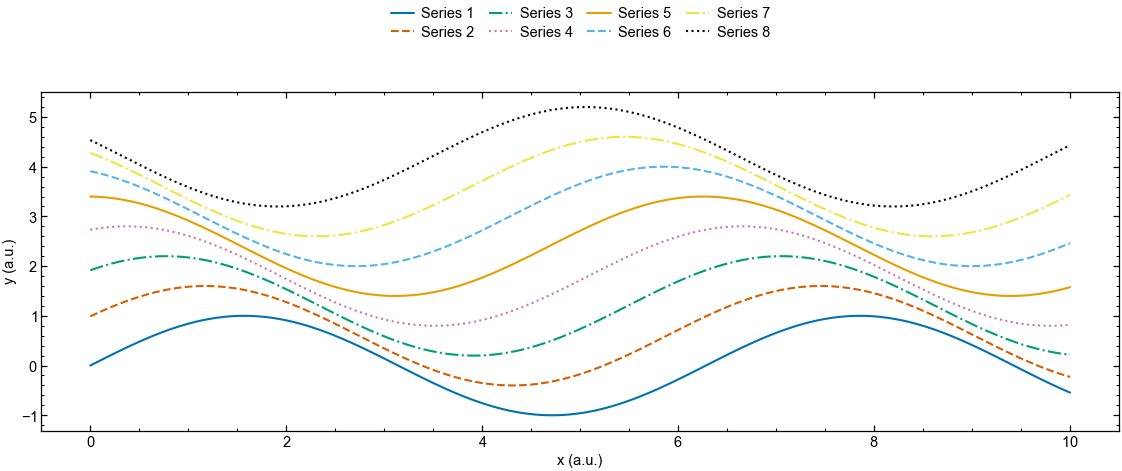

In [2]:
preview("elsevier")

x = np.linspace(0, 10, 400)
fig, ax = jf.subplots("elsevier", width="double", ratio=0.42)
for i in range(8):
    ax.plot(x, np.sin(x + i * 0.4) + i * 0.6, label=f"Series {i + 1}")
ax.set_xlabel("x (a.u.)")
ax.set_ylabel("y (a.u.)")
ax.legend(ncols=4, loc="upper center", bbox_to_anchor=(0.5, 1.28))

## Label the lines, not a legend box

A legend costs space and makes the reader look up a colour before they can read the plot. At 89 mm
that lookup is the most expensive thing on the page. `jf.label_lines()` puts each name beside its own
line instead — leave room for it with `ax.margins(x=...)`, since the labels sit outside the axes.

Text(0, 0.5, 'y (a.u.)')

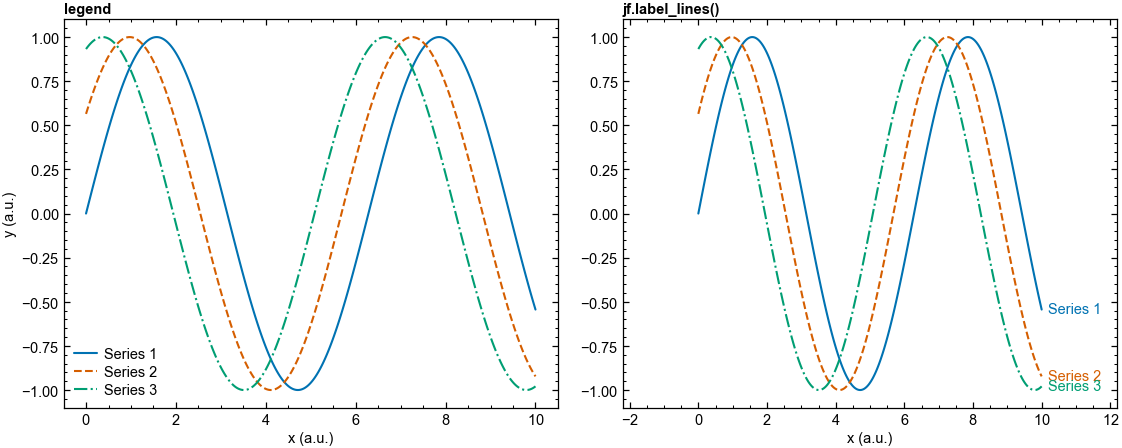

In [3]:
preview("elsevier")
fig, axs = jf.subplots("elsevier", 1, 2, width="double", ratio=0.4)

for i in range(3):
    axs[0].plot(x, np.sin(x + i * 0.6), label=f"Series {i + 1}")
    axs[1].plot(x, np.sin(x + i * 0.6), label=f"Series {i + 1}")

axs[0].legend()
axs[0].set_title("legend")

axs[1].margins(x=0.22)          # room for the labels, which sit outside the axes
jf.label_lines(axs[1])
axs[1].set_title("jf.label_lines()")

for ax in axs:
    ax.set_xlabel("x (a.u.)")
axs[0].set_ylabel("y (a.u.)")

## Does it survive greyscale?

Render the cycle, then desaturate it. The linestyles carry the distinction once the hues collapse.

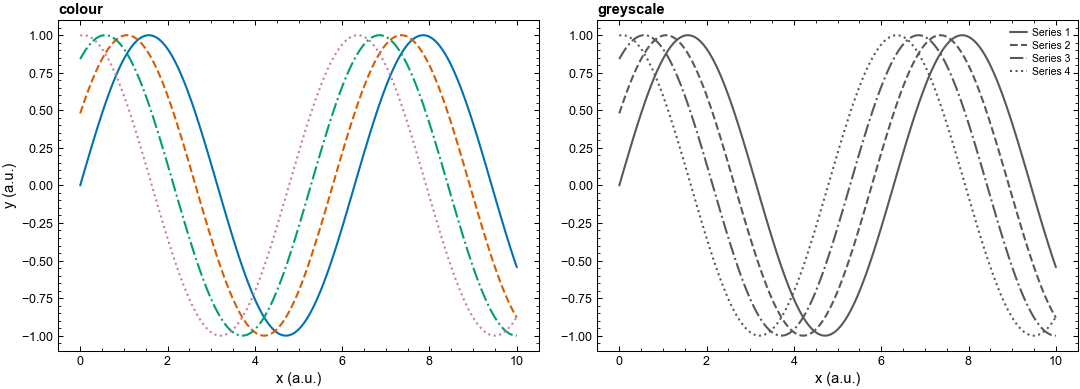

In [4]:
preview("nature")
fig, axs = jf.subplots("nature", 1, 2, width="double", ratio=0.36)

for ax, grey in zip(axs, [False, True]):
    for i in range(4):
        colour = "0.35" if grey else jf.COLOR_CYCLE[i]
        ax.plot(x, np.sin(x + i * 0.5), color=colour, linestyle=jf.LINESTYLE_CYCLE[i], label=f"Series {i + 1}")
    ax.set_xlabel("x (a.u.)")
    ax.set_title("greyscale" if grey else "colour")
axs[0].set_ylabel("y (a.u.)")
axs[1].legend(fontsize=5)

## Minimum line weight

APS requires printed lines of at least 0.5 pt. A hairline that looks fine on screen disappears in
print, and `jf.check()` reports it.

In [5]:
jf.use("aps")
fig, ax = jf.subplots("aps", width="single")
ax.plot(x, np.sin(x), linewidth=0.2)
ax.set_xlabel("x (a.u.)")
ax.set_ylabel("y (a.u.)")

for violation in jf.check(fig, warn=False):
    print(violation)
plt.close(fig)

[line] a line is 0.20 pt, below the 0.50 pt minimum


## Markers on a dense curve

`markevery` keeps a marked line legible instead of drawing a marker on all 400 points.

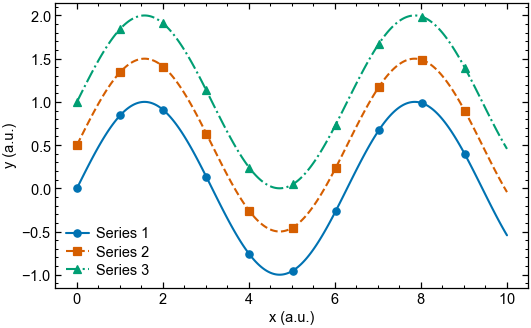

In [6]:
preview("elsevier")
fig, ax = jf.subplots("elsevier", width="single")
for i, marker in enumerate(jf.MARKER_CYCLE[:3]):
    ax.plot(x, np.sin(x) + i * 0.5, marker=marker, markevery=40, label=f"Series {i + 1}")
ax.set_xlabel("x (a.u.)")
ax.set_ylabel("y (a.u.)")
ax.legend()

## Bands and shaded regions

`fill_between` is the usual way to show a spread around a line. Transparency is preserved in PDF, SVG
and PNG — but not in EPS, where the PostScript backend flattens it to opaque. No theme writes EPS by
default for exactly that reason.

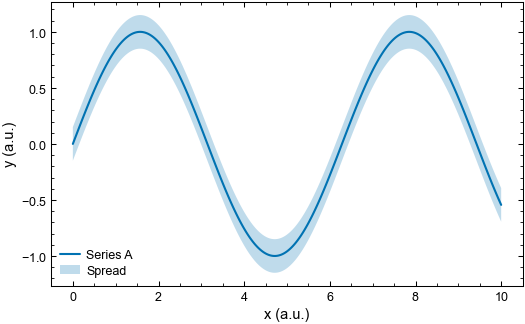

In [7]:
preview("nature")
y = np.sin(x)
fig, ax = jf.subplots("nature", width="single")
ax.plot(x, y, label="Series A")
ax.fill_between(x, y - 0.15, y + 0.15, alpha=0.25, linewidth=0, label="Spread")
ax.set_xlabel("x (a.u.)")
ax.set_ylabel("y (a.u.)")
ax.legend()

## Log scales

The themes turn minor ticks on, which is what you want on a log axis. `axes.formatter.use_mathtext`
is on too, so offset text is typeset rather than printed as `1e-3`.

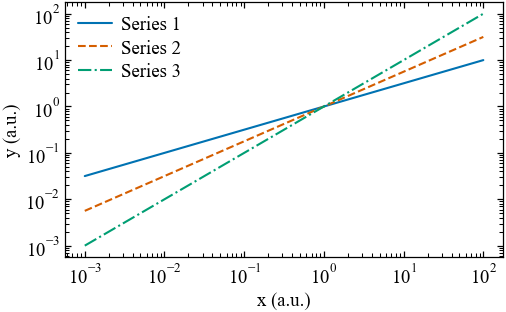

In [8]:
preview("aps")
decades = np.logspace(-3, 2, 200)
fig, ax = jf.subplots("aps", width="single")
for i in range(3):
    ax.plot(decades, decades ** (0.5 + 0.25 * i), label=f"Series {i + 1}")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("x (a.u.)")
ax.set_ylabel("y (a.u.)")
ax.legend()

## The same figure, three journals

One data set, one loop, three compliant figures. Note the sizes and font sizes change; the colours
never do.

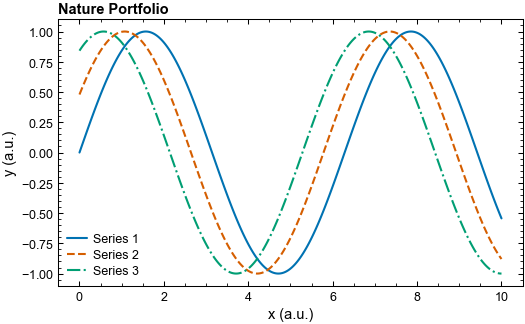

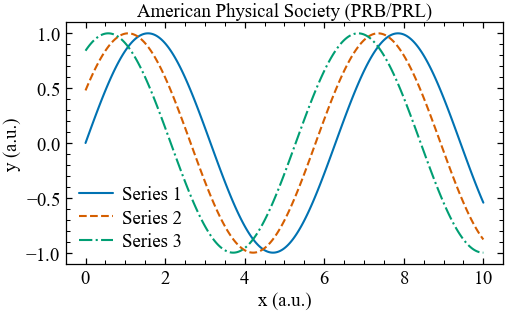

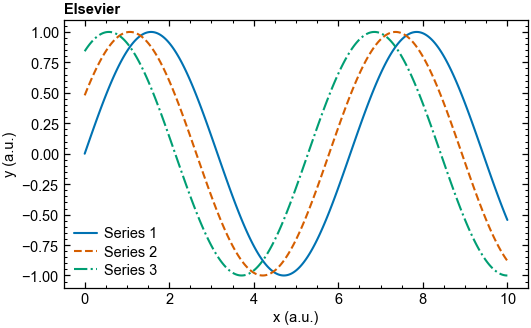

In [9]:
for journal in jf.JOURNALS:
    preview(journal)
    fig, ax = jf.subplots(journal, width="single")
    for i in range(3):
        ax.plot(x, np.sin(x + i * 0.5), label=f"Series {i + 1}")
    ax.set_xlabel("x (a.u.)")
    ax.set_ylabel("y (a.u.)")
    ax.set_title(jf.get_spec(journal).name)
    ax.legend()
    plt.show()